In [ ]:
# Huffman Coding Using Given Characters and Frequencies

import heapq

# Step 1: Input (manual)
chars = ['a','b','c','d','e','f']
freq  = [5,9,12,13,16,45]

# Step 2: Create list [freq, symbol]
nodes = []
for i in range(len(chars)):
    nodes.append([freq[i], chars[i]])

# Step 3: Build tree (combine smallest)
while len(nodes) > 1:
    nodes = sorted(nodes, key=lambda x: x[0])   # sort by freq

    left = nodes[0]
    right = nodes[1]

    # combine two smallest
    new_node = [left[0] + right[0], left[1] + right[1]]

    nodes = nodes[2:]
    nodes.append(new_node)

# Step 4: Assign codes (simple automatic)
sorted_data = sorted(zip(chars, freq), key=lambda x: x[1], reverse=True)

codes = {}
code = ""

for i in range(len(sorted_data)):
    ch = sorted_data[i][0]
    codes[ch] = code if code != "" else "0"
    code = code + "1"

# Step 5: Print codes
print("\nHuffman Codes:")
for k in codes:
    print(k, "=", codes[k])

# Step 6: Compression calculation
total = sum(freq)

original_bits = total * 8

compressed_bits = 0
for i in range(len(chars)):
    compressed_bits += freq[i] * len(codes[chars[i]])

ratio = original_bits / compressed_bits

print("\nCompression Ratio:", round(ratio,2))


Huffman Codes:
f = 0
e = 1
d = 11
c = 111
b = 1111
a = 11111

Compression Ratio: 4.35


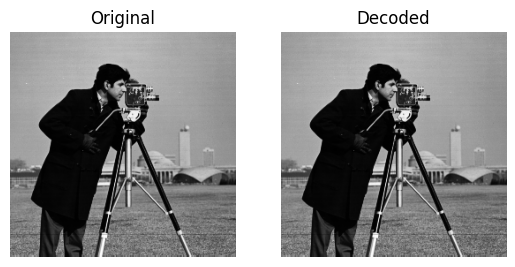

In [ ]:
import cv2
import numpy as np
import heapq
import matplotlib.pyplot as plt

# -------------------------------
# STEP 1: Read image
# -------------------------------
img = cv2.imread("/content/cameraman.bmp", 0)

rows, cols = img.shape

# -------------------------------
# STEP 2: Frequency using ARRAY
# -------------------------------
freq = np.zeros(256, dtype=int)

for i in range(rows):
    for j in range(cols):
        pixel = img[i][j]
        freq[pixel] = freq[pixel] + 1

# -------------------------------
# STEP 3: Create heap
# -------------------------------
heap = []

for pixel in range(256):
    if freq[pixel] > 0:
        node = [] #pair

        node.append(freq[pixel])          # frequency
        node.append([[pixel, ""]])        # pixel + code
        heap.append(node)

heapq.heapify(heap)

# -------------------------------
# STEP 4: Build Huffman Tree
# -------------------------------
while len(heap) > 1:

    left = heapq.heappop(heap)
    right = heapq.heappop(heap)

    # Assign 0 to left
    for item in left[1]:
        item[1] = "0" + item[1]

    # Assign 1 to right
    for item in right[1]:
        item[1] = "1" + item[1]

    # Combine nodes
    new_freq = left[0] + right[0]

    new_node = []
    new_node.append(new_freq)
    new_node.append(left[1] + right[1])

    heapq.heappush(heap, new_node)

# -------------------------------
# STEP 5: Generate codes
# -------------------------------
codes = {}

for item in heap[0][1]:
    pixel_value = item[0]
    code_value = item[1]
    codes[pixel_value] = code_value

# -------------------------------
# STEP 6: Encode image
# -------------------------------
encoded_bits = ""

for i in range(rows):
    for j in range(cols):
        pixel = img[i][j]
        encoded_bits = encoded_bits + codes[pixel]

# -------------------------------
# STEP 7: Convert bits → bytes
# -------------------------------
length_bits = len(encoded_bits)

extra_bits = 8 - (length_bits % 8)

for i in range(extra_bits):
    encoded_bits = encoded_bits + "0"

encoded_bytes = bytearray()

for i in range(0, len(encoded_bits), 8):
    byte = encoded_bits[i:i+8]
    value = int(byte, 2)
    encoded_bytes.append(value)

# Save compressed file
file = open("compressed.bin", "wb")
file.write(encoded_bytes)
file.close()

# -------------------------------
# STEP 8: Read file
# -------------------------------
file = open("compressed.bin", "rb")
data = file.read()
file.close()

# Convert bytes → bits
bits = ""

for byte in data:
    binary = format(byte, '08b')
    bits = bits + binary

# -------------------------------
# STEP 9: Decode
# -------------------------------
reverse = {}

for key in codes:
    value = codes[key]
    reverse[value] = key

decoded = []
temp = ""

for bit in bits:
    temp = temp + bit

    if temp in reverse:
        pixel_value = reverse[temp]
        decoded.append(pixel_value)
        temp = ""

# Remove extra bits
decoded = decoded[0:rows * cols]

# -------------------------------
# STEP 10: Reconstruct image
# -------------------------------
decoded_array = np.array(decoded, dtype=np.uint8)
decoded_img = decoded_array.reshape(rows, cols)

# -------------------------------
# STEP 11: Display
# -------------------------------
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(decoded_img, cmap='gray')
plt.title("Decoded")
plt.axis("off")

plt.show()